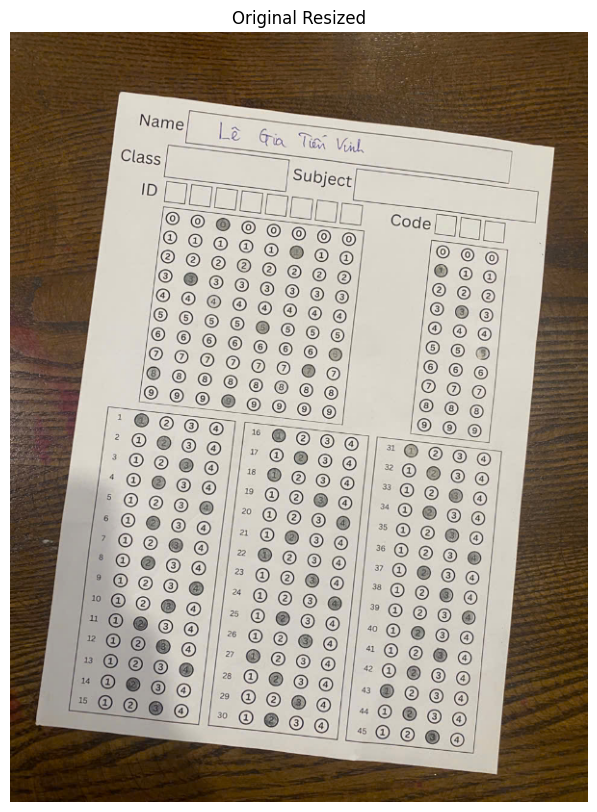

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(img, title="Image", cmap=None, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap if cmap else 'gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def resize(img, height=800):
    """ Resize image to given height """
    rat = height / img.shape[0]
    return cv2.resize(img, (int(rat * img.shape[1]), height))

# Đọc ảnh gốc
image_path = r"D:\OCR\data\4a6b7a9056b7d7e98ea6.jpg"
image = cv2.imread(image_path)
if image is None:
    print(f"Không tìm thấy ảnh tại {image_path}")
else:
    img_resized = resize(image)
    show_image(img_resized, "Original Resized")

### Bước 1: Grayscale & Bilateral Filter
Chuyển ảnh sang thang độ xám và lọc nhiễu nhưng vẫn giữ được các cạnh.

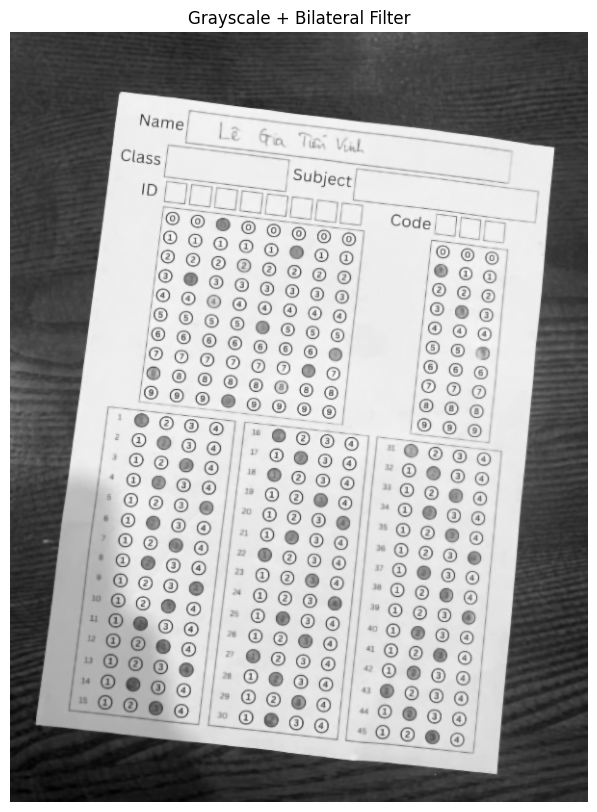

In [2]:
# Resize and convert to grayscale
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Bilateral filter: lọc nhiễu nhưng giữ cạnh (preserving edges)
img_bilateral = cv2.bilateralFilter(img_gray, 5, 75, 75)

show_image(img_bilateral, "Grayscale + Bilateral Filter")

### Bước 2: Adaptive Threshold & Median Blur
Tạo ảnh đen trắng dựa trên ngưỡng thích nghi và làm mượt để loại bỏ các chi tiết nhỏ dư thừa.

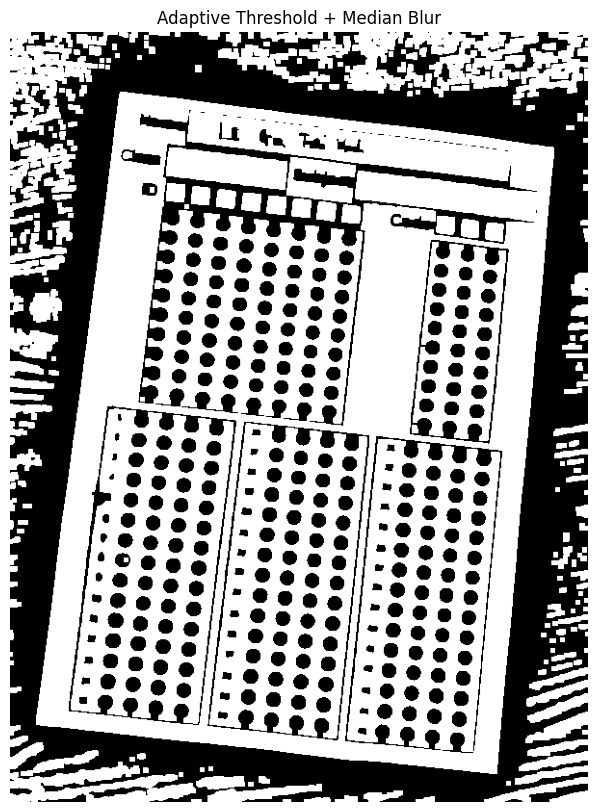

In [3]:
# Create black and white image based on adaptive threshold
img_thresh = cv2.adaptiveThreshold(img_bilateral, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 115, 4)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# Median filter: xóa các chấm nhỏ li ti
img_blurred = cv2.morphologyEx(img_thresh, cv2.MORPH_OPEN, kernel)

show_image(img_blurred, "Adaptive Threshold + Median Blur")

### Bước 3: Canny Edge Detection
Tìm các đường biên của vật thể.

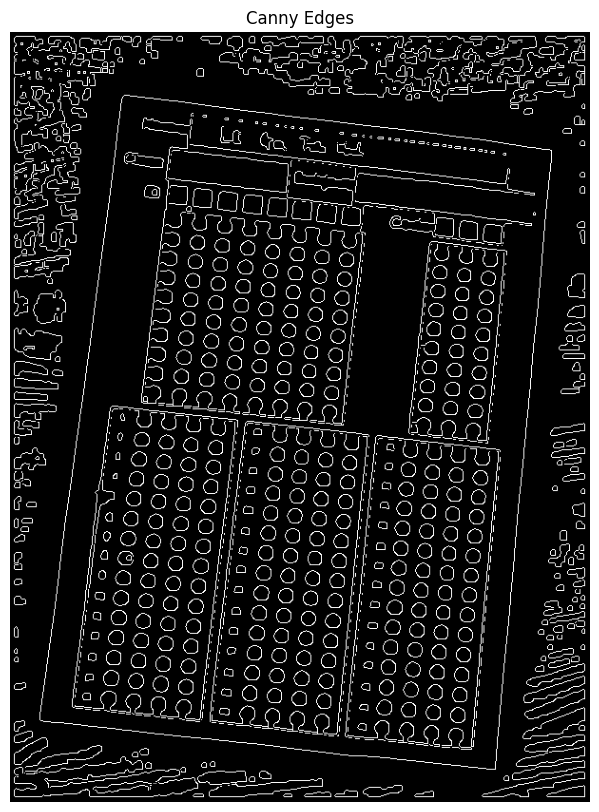

In [4]:
# Add black border (đề phòng tờ giấy chạm lề ảnh)
img_bordered = cv2.copyMakeBorder(img_blurred, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=[0, 0, 0])

edges = cv2.Canny(img_bordered, 10, 450)

show_image(edges, "Canny Edges")

### Bước 4: Tìm Contours (Đường viền giấy)
Tìm contour lớn nhất có hình dạng 4 góc.

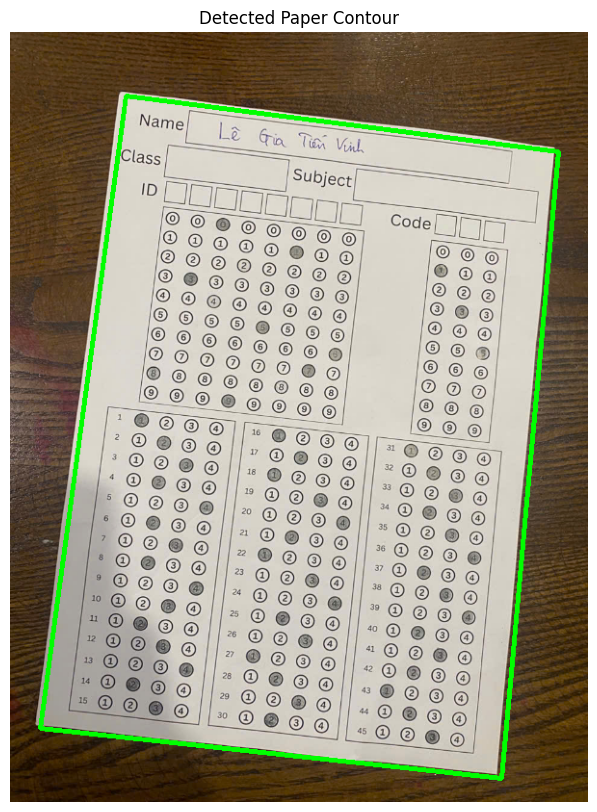

In [5]:
# Nối liền các cạnh bị đứt đoạn
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed_edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

height, width = edges.shape
MAX_COUNTOUR_AREA = (width - 10) * (height - 10)
maxAreaFound = MAX_COUNTOUR_AREA * 0.1

# Mặc định là toàn bộ khung hình nếu không tìm thấy
pageContour = np.array([[[5, 5]], [[5, height-5]], [[width-5, height-5]], [[width-5, 5]]])

for cnt in contours:
    perimeter = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.03 * perimeter, True)

    if (len(approx) == 4 and
            cv2.isContourConvex(approx) and
            maxAreaFound < cv2.contourArea(approx) < MAX_COUNTOUR_AREA):
        maxAreaFound = cv2.contourArea(approx)
        pageContour = approx

# Vẽ contour tìm được lên ảnh gốc (đã resize) để kiểm tra
img_contour = img_resized.copy()
cv2.drawContours(img_contour, [pageContour], -1, (0, 255, 0), 3)
show_image(img_contour, "Detected Paper Contour")

### Bước 5: Perspective Transform (Sửa biến dạng)
Cắt và xoay tờ giấy về dạng mặt phẳng thẳng.

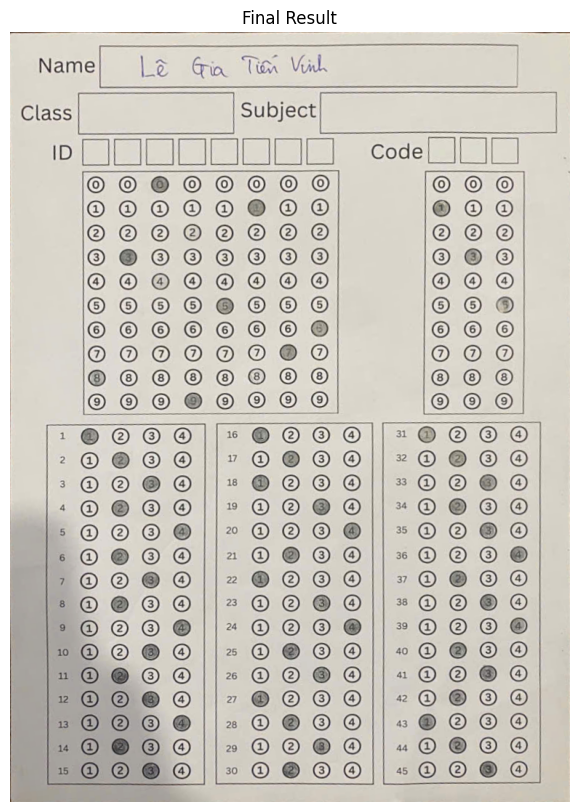

Đã lưu kết quả vào resultImage.jpg


In [6]:
def fourCornersSort(pts):
    """ Sort corners: top-left, top-right, bot-right, bot-left """
    diff = np.diff(pts, axis=1)
    summ = pts.sum(axis=1)
    
    # np.argmin() returns INDEX of min
    return np.array([pts[np.argmin(summ)],
                     pts[np.argmin(diff)],
                     pts[np.argmax(summ)],
                     pts[np.argmax(diff)]])

def contourOffset(cnt, offset):
    """ Offset contour, by 5px border """
    # Matrix addition
    cnt += offset
    
    # if value < 0 => replace it by 0
    cnt[cnt < 0] = 0
    return cnt


# Chuẩn bị điểm
pageContour = pageContour.reshape(4, 2)
pageContour = fourCornersSort(pageContour)
pageContour = contourOffset(pageContour, (-5, -5))

# Tính toán kích thước ảnh gốc
ratio = image.shape[0] / 800
sPoints = pageContour.dot(ratio)
  
# Using Euclidean distance
height = max(np.linalg.norm(sPoints[0] - sPoints[3]),
             np.linalg.norm(sPoints[1] - sPoints[2]))
width = max(np.linalg.norm(sPoints[0] - sPoints[1]),
            np.linalg.norm(sPoints[2] - sPoints[3]))

# Create target points
tPoints = np.array([[0, 0],
                    [width, 0],
                    [width, height],
                    [0, height]], np.float32)

# getPerspectiveTransform() needs float32
if sPoints.dtype != np.float32:
    sPoints = sPoints.astype(np.float32)

# Wraping perspective
M = cv2.getPerspectiveTransform(sPoints, tPoints) 
final_image = cv2.warpPerspective(image, M, (int(width), int(height)))

show_image(final_image, "Final Result")

# Saving the result. Yay! (don't forget to convert colors bait to BGR)
cv2.imwrite("resultImage.jpg", final_image)
print("Đã lưu kết quả vào resultImage.jpg")